# JABARULIN AI v2
## Semantic Review-Based Tourism Recommendation System

Sistem rekomendasi wisata Jawa Barat berbasis AI menggunakan arsitektur baru:

**Model Akademik (Training & Evaluasi):**
- TF-IDF → Feature Extraction dari review
- Logistic Regression → Klasifikasi Kategori Wisata
- Evaluasi: Accuracy, Precision, Recall, F1 Score, Confusion Matrix

**Model Rekomendasi Utama:**
- SentenceTransformer (paraphrase-multilingual-MiniLM-L12-v2) → Semantic Embedding
- Cosine Similarity → Semantic Search pada Review Corpus
- Hybrid Ranking → 75% Semantic Similarity + 15% Rating + 10% Review Count
- Negation Post-Filter → Menyaring hasil yang dinegasikan pengguna

**Perubahan dari Arsitektur Lama:**
- ❌ Tidak lagi menggunakan IndoBERT untuk intent classification
- ❌ Tidak lagi bergantung pada intent_label untuk filtering
- ✅ Review pengunjung menjadi sumber pengetahuan utama
- ✅ Semantic search memahami konteks & negasi lebih baik
- ✅ Dataset kembali ke sumber asli (data wisata jawabarat.xlsx)
- ✅ 37 kategori dikelompokkan menjadi 8 grup untuk klasifikasi yang lebih baik

---
## 1. Setup Environment & Library Imports

In [1]:
!pip install scikit-learn sentence-transformers openpyxl matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import pickle
import os
import re
import random
import shutil
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

# Scikit-Learn untuk ML Tradisional & Evaluasi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

# Sentence Transformers untuk Semantic Search
from sentence_transformers import SentenceTransformer

# Suppress warnings
warnings.filterwarnings('ignore')

# Mengunci random seed agar hasil selalu konsisten
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("✅ Semua library berhasil diimport!")
print("📦 Versi scikit-learn:", __import__('sklearn').__version__)
print("📦 Versi sentence-transformers:", __import__('sentence_transformers').__version__)

✅ Semua library berhasil diimport!
📦 Versi scikit-learn: 1.6.1
📦 Versi sentence-transformers: 5.5.1


---
## 2. Data Loading & Preprocessing

Menggunakan dataset asli `data wisata jawabarat.xlsx` sebagai sumber utama.

Kolom yang digunakan:
- `name` → Nama tempat wisata
- `category` → Kategori wisata asli (37 jenis)
- `category_group` → Kategori yang dikelompokkan (8 grup)
- `rating` → Rating tempat wisata
- `total_reviews` → Jumlah review (indikator popularitas)
- `all_reviews` → Review asli pengunjung
- `cleaned_reviews` → Review yang sudah dibersihkan
- `clean_content` → Konten bersih tambahan

In [2]:
print("="*70)
print("TAHAP 2: DATA LOADING & PREPROCESSING")
print("="*70)

# ============================================================
# 2.1 Membaca Dataset Asli
# ============================================================
print("\n📂 1. Membaca dataset asli (data wisata jawabarat.xlsx)...")
df = pd.read_excel('data wisata jawabarat.xlsx', sheet_name='bersih bersih')

print(f"   Jumlah Data Awal: {len(df)} baris")
print(f"   Kolom: {list(df.columns)}")

# ============================================================
# 2.2 Preprocessing
# ============================================================
print("\n🔧 2. Preprocessing data...")

# Normalisasi nama
df['name'] = df['name'].astype(str).str.title().str.strip()

# Handle missing values
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['total_reviews'] = pd.to_numeric(df['total_reviews'], errors='coerce')
df['rating'] = df['rating'].fillna(df['rating'].mean())
df['total_reviews'] = df['total_reviews'].fillna(0)
df['all_reviews'] = df['all_reviews'].fillna('')
df['cleaned_reviews'] = df['cleaned_reviews'].fillna('')
df['clean_content'] = df['clean_content'].fillna('')
df['category'] = df['category'].fillna('lainnya')

# ============================================================
# 2.3 Pengelompokan Kategori (37 → 8 grup)
# ============================================================
print("\n🏷️  3. Mengelompokkan kategori wisata...")
print(f"   Kategori asli: {df['category'].nunique()} jenis")

# Mapping kategori kecil/jarang ke grup yang lebih besar
# Ini diperlukan karena banyak kategori yang hanya memiliki 1-2 data,
# sehingga tidak bisa dilakukan stratified split untuk klasifikasi
category_mapping = {
    # Grup: Wisata Alam (tujuan wisata umum, pemandangan, air terjun, dll)
    'tujuan wisata': 'wisata alam',
    'area rekreasi alam': 'wisata alam',
    'wisata alam': 'wisata alam',
    'cagar alam': 'wisata alam',
    'titik pemandangan': 'wisata alam',
    'air terjun': 'wisata alam',
    'danau': 'wisata alam',
    'taman': 'wisata alam',
    # Grup: Gunung
    'gunung berapi': 'gunung',
    'puncak gunung': 'gunung',
    'area mendaki': 'gunung',
    # Grup: Pantai
    'pantai': 'pantai',
    'pantai umum': 'pantai',
    # Grup: Camping
    'bumi perkemahan': 'camping',
    'kabin perkemahan': 'camping',
    'kamp musim panas anak anak': 'camping',
    'kamp pelatihan': 'camping',
    # Grup: Adventure
    'rafting': 'adventure',
    'operator wisata rafting': 'adventure',
    'pusat olahraga petualangan': 'adventure',
    'jasa sewa kendaraan segala medan': 'adventure',
    # Grup: Keluarga & Rekreasi
    'kebun binatang': 'keluarga',
    'kolam renang': 'keluarga',
    'kolam renang umum': 'keluarga',
    'taman rekreasi air': 'keluarga',
    # Grup: Healing & Relaksasi
    'pemandian air panas': 'healing',
    'pemandian di ruang terbuka': 'healing',
    'pemandian umum luas': 'healing',
    'spa': 'healing',
    # Grup: Lainnya (hotel, non-wisata, dll)
    'hotel': 'lainnya',
    'hotel bintang 2': 'lainnya',
    'hotel bintang 4': 'lainnya',
    'hotel resor': 'lainnya',
    'bangunan bersejarah': 'lainnya',
    'event organizer eo': 'lainnya',
    'pembangkit listrik': 'lainnya',
    'produsen makanan': 'lainnya',
}

df['category_group'] = df['category'].map(category_mapping).fillna('lainnya')

print(f"   Kategori setelah pengelompokan: {df['category_group'].nunique()} grup")
print(f"\n   Distribusi Kategori Grup:")
print(df['category_group'].value_counts().to_string())

# ============================================================
# 2.4 Membuat Review Corpus (Gabungan semua teks review)
# ============================================================
print("\n📝 4. Membuat Review Corpus...")
print("   Menggabungkan: all_reviews + cleaned_reviews + clean_content")

df['review_corpus'] = (
    df['all_reviews'].astype(str) + ' ' +
    df['cleaned_reviews'].astype(str) + ' ' +
    df['clean_content'].astype(str)
).str.strip()

# Hapus baris yang review_corpus-nya kosong atau terlalu pendek
df = df[df['review_corpus'].str.len() > 10].reset_index(drop=True)

print(f"   Jumlah Data Setelah Filter: {len(df)} baris")

# ============================================================
# 2.5 Ringkasan Dataset
# ============================================================
print("\n📊 5. Ringkasan Dataset:")
print(f"   Total Wisata: {len(df)}")
print(f"   Wisata Unik: {df['name'].nunique()}")
print(f"   Kategori Asli: {df['category'].nunique()} jenis")
print(f"   Kategori Grup: {df['category_group'].nunique()} grup")
print(f"   Rating Range: {df['rating'].min():.1f} - {df['rating'].max():.1f}")
print(f"   Avg Rating: {df['rating'].mean():.2f}")

TAHAP 2: DATA LOADING & PREPROCESSING

📂 1. Membaca dataset asli (data wisata jawabarat.xlsx)...
   Jumlah Data Awal: 285 baris
   Kolom: ['name', 'category', 'address', 'phone', 'website', 'rating', 'total_reviews', 'google_maps_url', 'all_reviews', 'cleaned_reviews', 'clean_content']

🔧 2. Preprocessing data...

🏷️  3. Mengelompokkan kategori wisata...
   Kategori asli: 37 jenis
   Kategori setelah pengelompokan: 8 grup

   Distribusi Kategori Grup:
category_group
wisata alam    182
camping         33
gunung          18
pantai          18
keluarga        15
lainnya          9
healing          5
adventure        5

📝 4. Membuat Review Corpus...
   Menggabungkan: all_reviews + cleaned_reviews + clean_content
   Jumlah Data Setelah Filter: 285 baris

📊 5. Ringkasan Dataset:
   Total Wisata: 285
   Wisata Unik: 274
   Kategori Asli: 37 jenis
   Kategori Grup: 8 grup
   Rating Range: 3.5 - 5.0
   Avg Rating: 4.47


---
## 3. Model Akademik: TF-IDF + Logistic Regression

Model ini bertujuan untuk memenuhi kebutuhan akademik:
- Menunjukkan proses training machine learning
- Mengukur performa model dengan metrik evaluasi standar
- Membuktikan bahwa review pengunjung dapat digunakan untuk memahami karakteristik wisata

**Input:** `cleaned_reviews` (review bersih)  
**Target:** `category_group` (kategori wisata yang dikelompokkan menjadi 8 grup)  
**Algoritma:** TF-IDF + Logistic Regression

**Pengelompokan Kategori:**
- 37 kategori asli → 8 grup: wisata alam, gunung, pantai, camping, adventure, keluarga, healing, lainnya
- Semua data tetap digunakan, tidak ada yang dihapus

In [3]:
print("="*70)
print("TAHAP 3: MODEL AKADEMIK - TF-IDF + LOGISTIC REGRESSION")
print("="*70)

# ============================================================
# 3.1 Persiapan Data untuk Klasifikasi
# ============================================================
print("\n📋 1. Menyiapkan data untuk klasifikasi...")

# Gunakan cleaned_reviews sebagai input teks
# Target: category_group (kategori yang sudah dikelompokkan)
# Semua data digunakan, tidak ada yang dihapus
classification_df = df[df['cleaned_reviews'].str.len() > 10].copy()
print(f"   Data valid untuk klasifikasi: {len(classification_df)} baris")

X_text = classification_df['cleaned_reviews'].values
y_text = classification_df['category_group'].values

# Encode label kategori
le_category = LabelEncoder()
y_encoded = le_category.fit_transform(y_text)

print(f"   Jumlah Kategori: {len(le_category.classes_)}")
print(f"   Kategori: {list(le_category.classes_)}")
print(f"\n   Distribusi per kategori:")
for cat in le_category.classes_:
    count = (y_text == cat).sum()
    print(f"   - {cat}: {count} data")

# ============================================================
# 3.2 Train-Test Split
# ============================================================
print("\n✂️  2. Membagi dataset (80% Train, 20% Test)...")
X_train, X_test, y_train, y_test = train_test_split(
    X_text, y_encoded,
    test_size=0.2,
    random_state=SEED,
    stratify=y_encoded
)
print(f"   Data Train: {len(X_train)} | Data Test: {len(X_test)}")

# ============================================================
# 3.3 TF-IDF Vectorization
# ============================================================
print("\n🔤 3. Melakukan TF-IDF Vectorization...")
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"   TF-IDF Matrix Shape (Train): {X_train_tfidf.shape}")
print(f"   TF-IDF Matrix Shape (Test): {X_test_tfidf.shape}")

# ============================================================
# 3.4 Training Logistic Regression
# ============================================================
print("\n🚀 4. Training Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=SEED,
    class_weight='balanced',
    C=1.0,
    solver='lbfgs',
    multi_class='multinomial'
)

lr_model.fit(X_train_tfidf, y_train)
print("   ✅ Training selesai!")

TAHAP 3: MODEL AKADEMIK - TF-IDF + LOGISTIC REGRESSION

📋 1. Menyiapkan data untuk klasifikasi...
   Data valid untuk klasifikasi: 285 baris
   Jumlah Kategori: 8
   Kategori: ['adventure', 'camping', 'gunung', 'healing', 'keluarga', 'lainnya', 'pantai', 'wisata alam']

   Distribusi per kategori:
   - adventure: 5 data
   - camping: 33 data
   - gunung: 18 data
   - healing: 5 data
   - keluarga: 15 data
   - lainnya: 9 data
   - pantai: 18 data
   - wisata alam: 182 data

✂️  2. Membagi dataset (80% Train, 20% Test)...
   Data Train: 228 | Data Test: 57

🔤 3. Melakukan TF-IDF Vectorization...
   TF-IDF Matrix Shape (Train): (228, 10000)
   TF-IDF Matrix Shape (Test): (57, 10000)

🚀 4. Training Logistic Regression...
   ✅ Training selesai!


---
## 4. Evaluasi Model Akademik

Mengukur performa model klasifikasi menggunakan:
- **Accuracy** → Persentase prediksi benar secara keseluruhan
- **Precision** → Ketepatan prediksi positif
- **Recall** → Kemampuan mendeteksi kelas yang benar
- **F1 Score** → Harmonic mean dari Precision dan Recall
- **Confusion Matrix** → Visualisasi distribusi prediksi vs aktual

TAHAP 4: EVALUASI MODEL AKADEMIK

📊 Hasil Evaluasi Model:
   ┌─────────────────────────────────┐
   │ Accuracy  : 0.8421 (84.21%)  │
   │ Precision : 0.8572 (85.72%)  │
   │ Recall    : 0.8421 (84.21%)  │
   │ F1 Score  : 0.8317 (83.17%)  │
   └─────────────────────────────────┘

📋 Classification Report (Per Kategori):
              precision    recall  f1-score   support

   adventure       0.00      0.00      0.00         1
     camping       0.78      1.00      0.88         7
      gunung       1.00      1.00      1.00         4
     healing       0.00      0.00      0.00         1
    keluarga       1.00      0.33      0.50         3
     lainnya       1.00      0.50      0.67         2
      pantai       0.50      1.00      0.67         3
 wisata alam       0.91      0.89      0.90        36

    accuracy                           0.84        57
   macro avg       0.65      0.59      0.58        57
weighted avg       0.86      0.84      0.83        57


📈 Confusion Matrix:


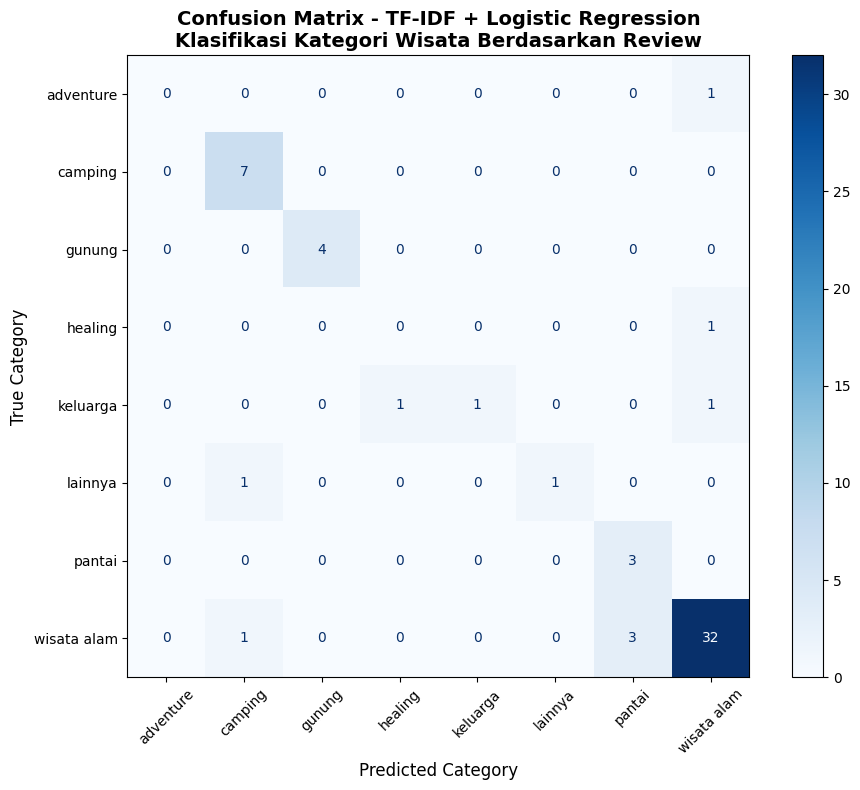

   ✅ Confusion matrix disimpan sebagai 'confusion_matrix.png'


In [4]:
print("="*70)
print("TAHAP 4: EVALUASI MODEL AKADEMIK")
print("="*70)

# ============================================================
# 4.1 Prediksi pada data test
# ============================================================
y_pred = lr_model.predict(X_test_tfidf)

# ============================================================
# 4.2 Menghitung Metrik Evaluasi
# ============================================================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("\n📊 Hasil Evaluasi Model:")
print(f"   ┌─────────────────────────────────┐")
print(f"   │ Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)  │")
print(f"   │ Precision : {precision:.4f} ({precision*100:.2f}%)  │")
print(f"   │ Recall    : {recall:.4f} ({recall*100:.2f}%)  │")
print(f"   │ F1 Score  : {f1:.4f} ({f1*100:.2f}%)  │")
print(f"   └─────────────────────────────────┘")

# ============================================================
# 4.3 Classification Report Detail
# ============================================================
print("\n📋 Classification Report (Per Kategori):")
print(classification_report(
    y_test, y_pred,
    target_names=le_category.classes_,
    zero_division=0
))

# ============================================================
# 4.4 Confusion Matrix Visualization
# ============================================================
print("\n📈 Confusion Matrix:")
fig, ax = plt.subplots(figsize=(10, 8))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le_category.classes_
)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, values_format='d')
ax.set_title('Confusion Matrix - TF-IDF + Logistic Regression\nKlasifikasi Kategori Wisata Berdasarkan Review', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Category', fontsize=12)
ax.set_ylabel('True Category', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✅ Confusion matrix disimpan sebagai 'confusion_matrix.png'")

---
## 5. Model Rekomendasi Utama: Semantic Search Engine

Membangun sistem rekomendasi berbasis semantic search menggunakan:
- **SentenceTransformer** (`paraphrase-multilingual-MiniLM-L12-v2`)
- Review corpus sebagai knowledge base
- Cosine similarity untuk mengukur kesesuaian

### Alur:
```
User Query → Embedding → Similarity Search → Review Corpus → Ranking → Recommendation
```

In [5]:
print("="*70)
print("TAHAP 5: MEMBANGUN SEMANTIC SEARCH ENGINE")
print("="*70)

# ============================================================
# 5.1 Load SentenceTransformer Model
# ============================================================
print("\n🤖 1. Memuat model SentenceTransformer...")
print("   Model: paraphrase-multilingual-MiniLM-L12-v2")
sbert_model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')
print("   ✅ Model berhasil dimuat!")

# ============================================================
# 5.2 Encode Review Corpus menjadi Embeddings
# ============================================================
print("\n🔢 2. Mengodekan review corpus ke dalam embeddings...")
print(f"   Memproses {len(df)} review...")

review_corpus_list = df['review_corpus'].tolist()
review_embeddings = sbert_model.encode(
    review_corpus_list,
    show_progress_bar=True,
    batch_size=32
)

print(f"   ✅ Embeddings Shape: {review_embeddings.shape}")
print(f"   Dimensi per vektor: {review_embeddings.shape[1]}")

TAHAP 5: MEMBANGUN SEMANTIC SEARCH ENGINE

🤖 1. Memuat model SentenceTransformer...
   Model: paraphrase-multilingual-MiniLM-L12-v2


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

   ✅ Model berhasil dimuat!

🔢 2. Mengodekan review corpus ke dalam embeddings...
   Memproses 285 review...


Batches:   0%|          | 0/9 [00:00<?, ?it/s]

   ✅ Embeddings Shape: (285, 384)
   Dimensi per vektor: 384


---
## 6. Hybrid Ranking & Recommendation Function

### Formula ranking akhir:
```
Final Score = 0.75 × Semantic Similarity + 0.15 × Rating Score + 0.10 × Review Score
```

- **Semantic Similarity (75%):** Kesesuaian review dengan query pengguna
- **Rating Score (15%):** Kualitas destinasi berdasarkan rating pengguna
- **Review Score (10%):** Popularitas berdasarkan jumlah review

### Negation Post-Filter:
Setelah semantic search, sistem mendeteksi kata negasi dalam query pengguna dan menyaring hasil berdasarkan 3 kolom sekaligus:
1. **`name`** → Menangkap "Pantai Citepus" yang kategorinya `tujuan wisata`
2. **`category`** → Menangkap "Sayang Heulang" yang kategorinya `pantai` tapi namanya tidak mengandung "pantai"
3. **`category_group`** → Menangkap berdasarkan grup yang sudah dimapping

In [6]:
print("="*70)
print("TAHAP 6: MEMBANGUN HYBRID RANKING SYSTEM")
print("="*70)

# ============================================================
# 6.1 Normalisasi Rating dan Total Reviews
# ============================================================
print("\n📐 1. Normalisasi skor rating dan total_reviews...")

# Normalisasi rating ke 0-1 (rating sudah dalam skala 0-5)
df['rating_normalized'] = df['rating'] / 5.0

# Normalisasi total_reviews menggunakan MinMaxScaler
scaler = MinMaxScaler()
df['reviews_normalized'] = scaler.fit_transform(df[['total_reviews']])

print(f"   Rating Normalized Range: {df['rating_normalized'].min():.3f} - {df['rating_normalized'].max():.3f}")
print(f"   Reviews Normalized Range: {df['reviews_normalized'].min():.3f} - {df['reviews_normalized'].max():.3f}")

# ============================================================
# 6.2 Negation Detection & Multi-Column Filter
# ============================================================
print("\n🚫 2. Mendefinisikan fungsi deteksi negasi...")

# Keyword yang akan dicek di kolom name dan category
GROUP_FILTER_KEYWORDS = {
    'gunung': ['gunung', 'gn ', 'gn.', 'puncak', 'kawah', 'mendaki'],
    'pantai': ['pantai', 'beach', 'pesisir'],
    'camping': ['camping', 'camp', 'kemah', 'glamping', 'perkemahan'],
    'adventure': ['rafting', 'offroad', 'arung jeram', 'adventure'],
    'keluarga': ['zoo', 'kebun binatang'],
    'healing': ['spa', 'pemandian', 'hot spring'],
}

def detect_negated_categories(user_input):
    """
    Mendeteksi kategori wisata yang dinegasikan oleh pengguna.
    Contoh: "ga mau gunung" → ['gunung']

    Returns:
        list: Daftar category_group yang harus difilter
    """
    user_input_lower = user_input.lower()
    excluded = []

    # Kata-kata negasi dalam bahasa Indonesia
    negations = [
        'ga mau', 'gak mau', 'tidak mau', 'bukan', 'selain',
        'hindari', 'tanpa', 'jangan', 'ga usah', 'gak usah',
        'males', 'ogah', 'no'
    ]

    # Mapping keyword dalam query → category_group
    keyword_to_group = {
        'gunung': ['gunung', 'muncak', 'puncak', 'pendakian', 'nanjak', 'kawah', 'mendaki'],
        'pantai': ['pantai', 'laut', 'pesisir', 'beach'],
        'camping': ['camping', 'camp', 'ngecamp', 'kemah', 'tenda', 'glamping'],
        'adventure': ['rafting', 'offroad', 'caving', 'climbing', 'hiking',
                      'trekking', 'arung jeram', 'ekstrim', 'ekstrem'],
        'keluarga': ['keluarga', 'anak', 'family', 'zoo', 'kebun binatang'],
        'healing': ['healing', 'spa', 'pemandian', 'rendam'],
    }

    for neg in negations:
        for match in re.finditer(re.escape(neg), user_input_lower):
            rest = user_input_lower[match.end():]

            # Batasi scope jika ada kata kontras
            contrast = re.search(r'\b(tapi|tetapi|namun|cuma|tp)\b', rest)
            if contrast:
                rest = rest[:contrast.start()]

            for group, keywords in keyword_to_group.items():
                for kw in keywords:
                    if kw in rest:
                        excluded.append(group)
                        break

    return list(set(excluded))


def filter_negated_results(result_df, excluded_groups):
    """
    Filter hasil berdasarkan 3 kolom: name, category, dan category_group.

    Jika keyword ditemukan di SALAH SATU kolom, baris tersebut dihapus.
    Contoh:
    - 'Pantai Citepus' (category='tujuan wisata') → terfilter via name
    - 'Sayang Heulang' (category='pantai')        → terfilter via category
    - 'Gunung Manglayang' (category='area mendaki')→ terfilter via name + category_group
    """
    if not excluded_groups:
        return result_df

    # 1. Filter berdasarkan category_group
    group_mask = result_df['category_group'].isin(excluded_groups)

    # 2. Kumpulkan keyword untuk dicek di name dan category
    filter_keywords = []
    for group in excluded_groups:
        if group in GROUP_FILTER_KEYWORDS:
            filter_keywords.extend(GROUP_FILTER_KEYWORDS[group])
        # Tambahkan nama grup itu sendiri sebagai keyword
        filter_keywords.append(group)

    # 3. Filter berdasarkan keyword di name
    pattern = '|'.join(re.escape(kw) for kw in filter_keywords)
    name_mask = result_df['name'].str.lower().str.contains(pattern, regex=True, na=False)

    # 4. Filter berdasarkan keyword di category (raw)
    category_mask = result_df['category'].str.lower().str.contains(pattern, regex=True, na=False)

    # 5. Gabungkan: hapus jika ditemukan di SALAH SATU kolom
    combined_mask = group_mask | name_mask | category_mask
    filtered = result_df[~combined_mask].copy()

    return filtered


print("   ✅ Fungsi deteksi negasi berhasil didefinisikan!")

# Test deteksi negasi
test_negations = [
    'pengen dingin tapi ga mau gunung',
    'jangan pantai',
    'healing tanpa camping',
    'tempat seru selain rafting',
    'tempat wisata yang bagus',  # tidak ada negasi
]
print("\n   Test Deteksi Negasi:")
for test in test_negations:
    result = detect_negated_categories(test)
    print(f"   \"{test}\" → exclude: {result if result else '(tidak ada)'}")

# ============================================================
# 6.3 Fungsi Rekomendasi Semantik + Negation Filter
# ============================================================
print("\n🔧 3. Mendefinisikan fungsi rekomendasi...")

def semantic_recommendation(query, top_n=5, similarity_threshold=0.1):
    """
    Sistem rekomendasi wisata berbasis semantic search + negation filter.

    Args:
        query (str): Input pengguna dalam bahasa alami
        top_n (int): Jumlah rekomendasi yang ditampilkan
        similarity_threshold (float): Batas minimum similarity score

    Returns:
        pd.DataFrame: Rekomendasi wisata dengan skor
    """
    # Step 1: Deteksi negasi dalam query
    excluded_groups = detect_negated_categories(query)
    if excluded_groups:
        print(f"   🚫 Negasi terdeteksi → menyaring kategori: {excluded_groups}")

    # Step 2: Encode query pengguna
    query_embedding = sbert_model.encode([query])

    # Step 3: Hitung cosine similarity antara query dan semua review
    similarity_scores = cosine_similarity(query_embedding, review_embeddings).flatten()

    # Step 4: Buat dataframe hasil
    result_df = df.copy()
    result_df['semantic_similarity'] = similarity_scores

    # Step 5: Post-filter negasi (cek name + category + category_group)
    if excluded_groups:
        result_df = filter_negated_results(result_df, excluded_groups)

    # Step 6: Filter berdasarkan threshold
    result_df = result_df[result_df['semantic_similarity'] > similarity_threshold].copy()

    if result_df.empty:
        return pd.DataFrame()

    # Step 7: Hitung Hybrid Final Score
    # Formula: 0.75 × Semantic Similarity + 0.15 × Rating Score + 0.10 × Review Score
    result_df['final_score'] = (
        0.75 * result_df['semantic_similarity'] +
        0.15 * result_df['rating_normalized'] +
        0.10 * result_df['reviews_normalized']
    )

    # Step 8: Sort dan deduplicate berdasarkan nama
    result_df = result_df.sort_values(by='final_score', ascending=False)
    result_df = result_df.drop_duplicates(subset='name', keep='first')

    # Step 9: Ambil top-N rekomendasi
    recommendations = result_df.head(top_n).copy()

    # Format output
    recommendations['semantic_similarity'] = recommendations['semantic_similarity'].round(4)
    recommendations['final_score'] = recommendations['final_score'].round(4)
    recommendations['rating'] = recommendations['rating'].round(1)

    return recommendations[['name', 'category', 'category_group', 'rating', 'total_reviews',
                           'semantic_similarity', 'final_score']]

print("   ✅ Fungsi rekomendasi berhasil didefinisikan!")

TAHAP 6: MEMBANGUN HYBRID RANKING SYSTEM

📐 1. Normalisasi skor rating dan total_reviews...
   Rating Normalized Range: 0.700 - 1.000
   Reviews Normalized Range: 0.000 - 1.000

🚫 2. Mendefinisikan fungsi deteksi negasi...
   ✅ Fungsi deteksi negasi berhasil didefinisikan!

   Test Deteksi Negasi:
   "pengen dingin tapi ga mau gunung" → exclude: ['gunung']
   "jangan pantai" → exclude: ['pantai']
   "healing tanpa camping" → exclude: ['camping']
   "tempat seru selain rafting" → exclude: ['adventure']
   "tempat wisata yang bagus" → exclude: (tidak ada)

🔧 3. Mendefinisikan fungsi rekomendasi...
   ✅ Fungsi rekomendasi berhasil didefinisikan!


---
## 7. System Testing - Pengujian Sistem Rekomendasi

Menguji sistem dengan berbagai query untuk memvalidasi:
1. Pemahaman konteks bahasa alami
2. Penanganan negasi ("ga mau gunung")
3. Relevansi hasil berdasarkan review pengunjung
4. Kualitas hybrid ranking

In [7]:
print("="*70)
print("TAHAP 7: PENGUJIAN SISTEM REKOMENDASI")
print("="*70)

# Daftar query pengujian
test_queries = [
    'Pengen tempat dingin buat healing',
    'Pengen liburan yang dingin tapi ga mau di gunung',
    'pantai sunset bagus dan sepi',
    'tempat wisata untuk keluarga dan anak anak',
    'camping seru di alam terbuka',
    'rafting dan offroad yang menantang',
    'tempat romantis buat pacaran',
    'wisata alam yang sejuk dan tenang untuk relaksasi',
    'liburan seru tapi jangan pantai',
    'tempat dingin selain gunung dan camping'
]

for query in test_queries:
    print("\n" + "=" * 70)
    print(f"🔍 USER INPUT: \"{query}\"")
    print("=" * 70)

    recommendations = semantic_recommendation(query, top_n=5)

    if not recommendations.empty:
        print(recommendations.to_string(index=False))
    else:
        print("❌ Tidak ada rekomendasi yang ditemukan.")
    print()

TAHAP 7: PENGUJIAN SISTEM REKOMENDASI

🔍 USER INPUT: "Pengen tempat dingin buat healing"
                                            name        category category_group  rating  total_reviews  semantic_similarity  final_score
                            Tekad Camping Ground bumi perkemahan        camping     4.6            272               0.4543       0.4791
Air Terjun Curug Ciismun Kebun Raya Cibodas Brin   tujuan wisata    wisata alam     4.5            684               0.4071       0.4413
                                Maranganani Camp bumi perkemahan        camping     4.6            288               0.4015       0.4395
                                     Kawah Putih   tujuan wisata    wisata alam     4.5          16721               0.3703       0.4360
                    Taman Safari Indonesia Bogor  kebun binatang       keluarga     4.7          71710               0.2529       0.4307


🔍 USER INPUT: "Pengen liburan yang dingin tapi ga mau di gunung"
   🚫 Negasi terdeteksi

---
## 8. Evaluasi Sistem Rekomendasi (NDCG Score)

NDCG (Normalized Discounted Cumulative Gain) mengukur kualitas ranking:
- **1.0** = Ranking sempurna
- **< 1.0** = Ada ruang perbaikan dalam urutan rekomendasi

In [8]:
from sklearn.metrics import ndcg_score

print("="*70)
print("TAHAP 8: EVALUASI SISTEM REKOMENDASI (NDCG SCORE)")
print("="*70)

eval_queries = [
    'Pengen tempat dingin buat healing',
    'pantai sunset bagus dan sepi',
    'tempat wisata untuk keluarga dan anak anak',
    'camping seru di alam terbuka',
    'rafting dan offroad yang menantang',
]

ndcg_scores = []

for query in eval_queries:
    result = semantic_recommendation(query, top_n=5)

    if len(result) >= 2:
        predicted_scores = np.asarray([result['final_score'].tolist()])
        relevance_length = len(result)
        true_relevance = np.asarray([list(range(relevance_length, 0, -1))])

        ndcg = ndcg_score(true_relevance, predicted_scores)
        ndcg_scores.append(ndcg)
        print(f"\n  Query: \"{query}\"")
        print(f"  NDCG Score: {ndcg:.4f}")
    else:
        print(f"\n  Query: \"{query}\"")
        print(f"  ⚠️  Tidak cukup hasil untuk menghitung NDCG")

if ndcg_scores:
    avg_ndcg = np.mean(ndcg_scores)
    print(f"\n{'='*70}")
    print(f"📊 Rata-rata NDCG Score: {avg_ndcg:.4f}")
    print(f"   (Score 1.0000 = ranking sempurna)")
    print(f"{'='*70}")

TAHAP 8: EVALUASI SISTEM REKOMENDASI (NDCG SCORE)

  Query: "Pengen tempat dingin buat healing"
  NDCG Score: 1.0000

  Query: "pantai sunset bagus dan sepi"
  NDCG Score: 1.0000

  Query: "tempat wisata untuk keluarga dan anak anak"
  NDCG Score: 1.0000

  Query: "camping seru di alam terbuka"
  NDCG Score: 1.0000

  Query: "rafting dan offroad yang menantang"
  NDCG Score: 1.0000

📊 Rata-rata NDCG Score: 1.0000
   (Score 1.0000 = ranking sempurna)


---
## 9. Export & Save Model Artifacts

Menyimpan semua komponen model untuk deployment ke backend:
1. Model SBERT (SentenceTransformer)
2. Review Embeddings
3. Dataset yang sudah diproses
4. TF-IDF Vectorizer & Logistic Regression (model akademik)
5. Label Encoder
6. Scaler untuk normalisasi

In [9]:
print("="*70)
print("TAHAP 9: EXPORT & SAVE MODEL ARTIFACTS")
print("="*70)

save_path = './jabarulin_semantic_model'
os.makedirs(save_path, exist_ok=True)

# ============================================================
# 9.1 Simpan Model SBERT
# ============================================================
print("\n💾 1. Menyimpan model SentenceTransformer...")
sbert_save_path = f'{save_path}/sbert_model'
sbert_model.save(sbert_save_path)
print(f"   ✅ Disimpan di: {sbert_save_path}")

# ============================================================
# 9.2 Simpan Review Embeddings
# ============================================================
print("\n💾 2. Menyimpan review embeddings...")
with open(f'{save_path}/review_embeddings.pkl', 'wb') as f:
    pickle.dump(review_embeddings, f)
print(f"   ✅ Shape: {review_embeddings.shape}")

# ============================================================
# 9.3 Simpan Dataset yang Sudah Diproses
# ============================================================
print("\n💾 3. Menyimpan dataset yang sudah diproses...")
df.to_csv(f'{save_path}/processed_dataset.csv', index=False)
print(f"   ✅ {len(df)} baris disimpan")

# ============================================================
# 9.4 Simpan Model Akademik (TF-IDF + LR)
# ============================================================
print("\n💾 4. Menyimpan model akademik (TF-IDF + Logistic Regression)...")
with open(f'{save_path}/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

with open(f'{save_path}/logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

with open(f'{save_path}/label_encoder_category.pkl', 'wb') as f:
    pickle.dump(le_category, f)
print("   ✅ Disimpan: tfidf_vectorizer.pkl, logistic_regression_model.pkl, label_encoder_category.pkl")

# ============================================================
# 9.5 Simpan Scaler
# ============================================================
print("\n💾 5. Menyimpan scaler...")
with open(f'{save_path}/reviews_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("   ✅ Disimpan: reviews_scaler.pkl")

# ============================================================
# 9.6 Simpan Konfigurasi Model
# ============================================================
print("\n💾 6. Menyimpan konfigurasi model...")
config = {
    'model_version': 'v2.0',
    'architecture': 'Semantic Review-Based Recommendation',
    'sbert_model_name': 'paraphrase-multilingual-MiniLM-L12-v2',
    'academic_model': 'TF-IDF + Logistic Regression',
    'hybrid_weights': {
        'semantic_similarity': 0.75,
        'rating': 0.15,
        'review_count': 0.10
    },
    'dataset_source': 'data wisata jawabarat.xlsx',
    'total_destinations': len(df),
    'embedding_dimension': review_embeddings.shape[1],
    'category_groups': list(le_category.classes_),
    'category_mapping': category_mapping,
    'negation_filter_keywords': GROUP_FILTER_KEYWORDS,
    'evaluation_metrics': {
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1)
    }
}

with open(f'{save_path}/model_config.pkl', 'wb') as f:
    pickle.dump(config, f)
print("   ✅ Disimpan: model_config.pkl")

# ============================================================
# 9.7 Buat ZIP dan Download
# ============================================================
print("\n📦 7. Mengompres folder model menjadi ZIP...")
zip_filename = 'jabarulin_semantic_model'
shutil.make_archive(zip_filename, 'zip', save_path)
print(f"   ✅ ZIP berhasil dibuat: {zip_filename}.zip")

# Generate requirements.txt
print("\n📝 8. Membuat requirements.txt...")
!pip freeze > requirements.txt
print("   ✅ requirements.txt berhasil dibuat")

print("\n📥 9. Memulai proses download...")
files.download(f"{zip_filename}.zip")
files.download('requirements.txt')

print("\n" + "="*70)
print("🎉 SEMUA PROSES SELESAI!")
print("="*70)
print(f"\n📁 Isi folder '{save_path}':")
for f_name in os.listdir(save_path):
    f_path = os.path.join(save_path, f_name)
    if os.path.isdir(f_path):
        print(f"   📂 {f_name}/")
    else:
        size_mb = os.path.getsize(f_path) / (1024*1024)
        print(f"   📄 {f_name} ({size_mb:.2f} MB)")

TAHAP 9: EXPORT & SAVE MODEL ARTIFACTS

💾 1. Menyimpan model SentenceTransformer...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   ✅ Disimpan di: ./jabarulin_semantic_model/sbert_model

💾 2. Menyimpan review embeddings...
   ✅ Shape: (285, 384)

💾 3. Menyimpan dataset yang sudah diproses...
   ✅ 285 baris disimpan

💾 4. Menyimpan model akademik (TF-IDF + Logistic Regression)...
   ✅ Disimpan: tfidf_vectorizer.pkl, logistic_regression_model.pkl, label_encoder_category.pkl

💾 5. Menyimpan scaler...
   ✅ Disimpan: reviews_scaler.pkl

💾 6. Menyimpan konfigurasi model...
   ✅ Disimpan: model_config.pkl

📦 7. Mengompres folder model menjadi ZIP...
   ✅ ZIP berhasil dibuat: jabarulin_semantic_model.zip

📝 8. Membuat requirements.txt...
   ✅ requirements.txt berhasil dibuat

📥 9. Memulai proses download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 SEMUA PROSES SELESAI!

📁 Isi folder './jabarulin_semantic_model':
   📂 sbert_model/
   📄 tfidf_vectorizer.pkl (0.38 MB)
   📄 reviews_scaler.pkl (0.00 MB)
   📄 processed_dataset.csv (15.47 MB)
   📄 model_config.pkl (0.00 MB)
   📄 review_embeddings.pkl (0.42 MB)
   📄 logistic_regression_model.pkl (0.61 MB)
   📄 label_encoder_category.pkl (0.00 MB)
